In [ ]:
# ============================================================
# Q1(c) — Display Hidden→Output Weights in a Meaningful Way
# ============================================================
# W2 has shape (4, 3):  rows = [bias, h1, h2, h3],  cols = [out_B, out_0, out_E]
# Each OUTPUT unit j has 3 hidden weights W2[1:, j].
# Unlike W1, these cannot be reshaped into a pixel image — there are only 3 values.
 

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patches as mpatches

# ----------------------------------------------------------
# STEP 1 — Reproduce dataset & network (same as Q1-a / Q1-b)
# ----------------------------------------------------------

def make_template(letter: str) -> np.ndarray:
    """8×8 template: black pixel → -1.0, white pixel → +1.0."""
    W, B = +1.0, -1.0
    templates = {
        'B': np.array([
            [B,B,B,B,B,W,W,W],
            [B,W,W,W,B,W,W,W],
            [B,W,W,W,B,W,W,W],
            [B,B,B,B,B,W,W,W],
            [B,W,W,W,W,B,W,W],
            [B,W,W,W,W,B,W,W],
            [B,W,W,W,W,B,W,W],
            [B,B,B,B,B,W,W,W],
        ]),
        '0': np.array([
            [W,B,B,B,B,B,W,W],
            [B,W,W,W,W,W,B,W],
            [B,W,W,W,W,W,B,W],
            [B,W,W,W,W,W,B,W],
            [B,W,W,W,W,W,B,W],
            [B,W,W,W,W,W,B,W],
            [B,W,W,W,W,W,B,W],
            [W,B,B,B,B,B,W,W],
        ]),
        'E': np.array([
            [B,B,B,B,B,B,W,W],
            [B,W,W,W,W,W,W,W],
            [B,W,W,W,W,W,W,W],
            [B,B,B,B,W,W,W,W],
            [B,W,W,W,W,W,W,W],
            [B,W,W,W,W,W,W,W],
            [B,W,W,W,W,W,W,W],
            [B,B,B,B,B,B,W,W],
        ]),
    }
    return templates[letter]


def generate_dataset(n_per_class=100, noise_range=5.0, seed=42):
    """300 noisy samples (100 per class).  Returns X:(300,64), y:(300,3) one-hot."""
    rng = np.random.default_rng(seed)
    letters = ['B', '0', 'E']
    X_parts, y_parts = [], []
    for idx, letter in enumerate(letters):
        tmpl  = make_template(letter).flatten()
        noise = rng.uniform(-noise_range, noise_range, size=(n_per_class, 64))
        X_parts.append(tmpl + noise)
        lbl = np.zeros((n_per_class, 3))
        lbl[:, idx] = 1.0
        y_parts.append(lbl)
    return np.vstack(X_parts), np.vstack(y_parts)


class NeuralNet6433:
    """
    64 → 3 → 3  fully-connected network with bias.
    Hidden activation : tanh
    Output activation : linear  (MSE loss)
    Bias absorbed via a prepended +1 column.
    """
    def __init__(self, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, 0.1, (65, 3))   # (64 inputs + bias) → 3 hidden
        self.W2 = rng.normal(0, 0.1, (4,  3))   # (3 hidden + bias)  → 3 outputs

    @staticmethod
    def _add_bias(X): return np.hstack([np.ones((X.shape[0],1)), X])

    def forward(self, X):
        Xb  = self._add_bias(X)          # (N, 65)
        z1  = Xb @ self.W1               # (N, 3)  hidden pre-activation
        h   = np.tanh(z1)                # (N, 3)  hidden activation
        hb  = self._add_bias(h)          # (N, 4)
        out = hb @ self.W2               # (N, 3)  linear output
        return out, z1, h, Xb

    def backward(self, y, out, z1, h, Xb, lr=0.01):
        N        = y.shape[0]
        dL_dout  = (out - y) / N
        hb       = self._add_bias(h)
        dL_dW2   = hb.T @ dL_dout
        dL_dh    = dL_dout @ self.W2[1:].T
        dL_dz1   = dL_dh * (1 - np.tanh(z1)**2)
        dL_dW1   = Xb.T @ dL_dz1
        self.W2 -= lr * dL_dW2
        self.W1 -= lr * dL_dW1

    def train(self, X, y, epochs=5000, lr=0.01, verbose=True):
        losses = []
        for ep in range(epochs):
            out, z1, h, Xb = self.forward(X)
            loss = np.mean((out - y)**2)
            losses.append(loss)
            self.backward(y, out, z1, h, Xb, lr)
            if verbose and (ep+1) % 500 == 0:
                print(f"  Epoch {ep+1:5d}  MSE = {loss:.6f}")
        return losses


# ------ train ------
print("Generating dataset …")
X, y = generate_dataset()

print("Training 64-3-3 network …")
net   = NeuralNet6433(seed=0)
losses = net.train(X, y, epochs=5000, lr=0.01, verbose=True)

out_train, *_ = net.forward(X)
acc = (np.argmax(out_train,1) == np.argmax(y,1)).mean()
print(f"\nTraining accuracy : {acc*100:.1f}%")

Generating dataset …
Training 64-3-3 network …
  Epoch   500  MSE = 0.142347
  Epoch  1000  MSE = 0.088676
  Epoch  1500  MSE = 0.079712
  Epoch  2000  MSE = 0.075472
  Epoch  2500  MSE = 0.072291
  Epoch  3000  MSE = 0.069581
  Epoch  3500  MSE = 0.067778
  Epoch  4000  MSE = 0.066213
  Epoch  4500  MSE = 0.064422
  Epoch  5000  MSE = 0.062561

Training accuracy : 93.3%


Hidden→Output weight matrix  W2[1:, :]
                Output B    Output 0    Output E
Hidden 1      -0.1901  +0.0750  +0.1151
Hidden 2      +0.3228  -0.3384  +0.0155
Hidden 3      -0.1306  -0.2816  +0.4122
Bias          +0.4034  +0.2338  +0.3627


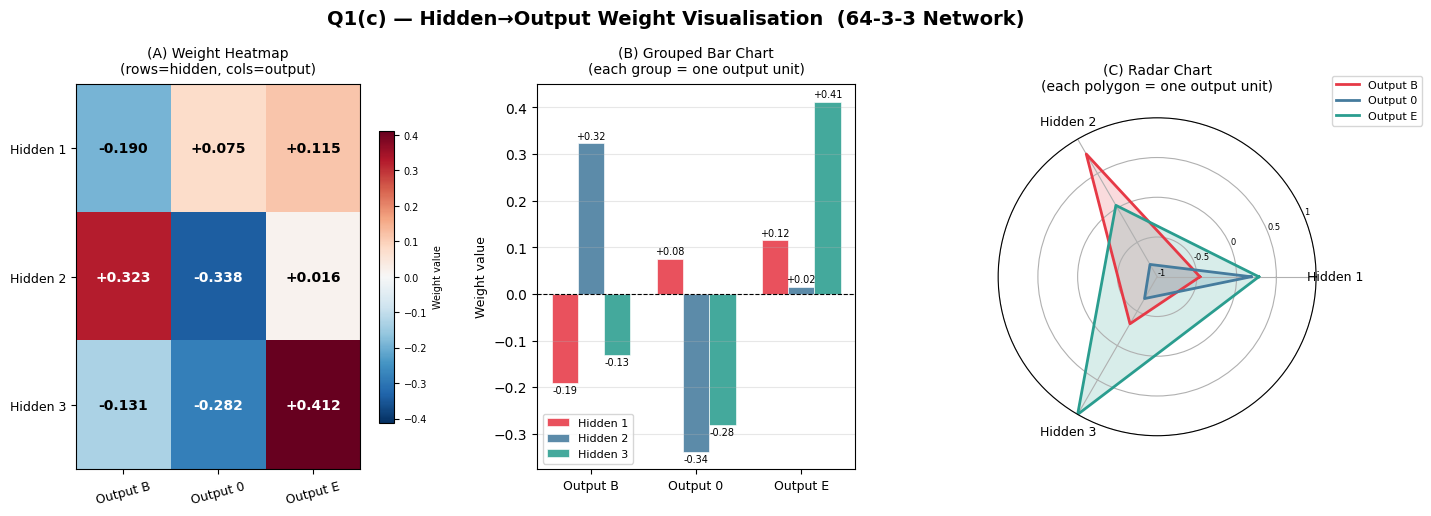

Figure saved as q1c_output_weight_visualization.png


In [ ]:
# ============================================================
# Q1(c) — Visualise Hidden→Output Weights  (W2)
# ============================================================
# W2 shape: (4, 3)
#   Rows: [bias_row, hidden_unit_1, hidden_unit_2, hidden_unit_3]
#   Cols: [output_B,  output_0,     output_E]
#
# We extract the 3×3 sub-matrix (rows 1-3) of meaningful pixel weights.
# Three complementary visualisations:
#   Panel A — Annotated Heatmap  : colour + number for every weight
#   Panel B — Grouped Bar Chart  : per-output bar group, one bar per hidden unit
#   Panel C — Radar / Spider Chart: per-output polygon over the 3 hidden units
# ============================================================

CLASS_NAMES  = ['Output B', 'Output 0', 'Output E']
HIDDEN_NAMES = ['Hidden 1', 'Hidden 2', 'Hidden 3']
COLORS       = ['#E63946', '#457B9D', '#2A9D8F']   # red, blue, teal

# Extract the 3×3 weight matrix  (hidden units × output units)
# W2[1:, :] → shape (3, 3)  — drop the bias row (row 0)
W2_hw = net.W2[1:, :]    # rows = hidden units (3), cols = output units (3)
bias2 = net.W2[0, :]     # bias of each output unit

print("Hidden→Output weight matrix  W2[1:, :]")
print(f"{'':12s}" + "".join(f"{c:>12s}" for c in CLASS_NAMES))
for i, hname in enumerate(HIDDEN_NAMES):
    vals = "  ".join(f"{W2_hw[i,j]:+.4f}" for j in range(3))
    print(f"{hname:12s}  {vals}")
print(f"{'Bias':12s}  " + "  ".join(f"{bias2[j]:+.4f}" for j in range(3)))

# ==============================================================
# Figure layout: 1 row, 3 panels
# ==============================================================
fig = plt.figure(figsize=(16, 5))
fig.suptitle("Q1(c) — Hidden→Output Weight Visualisation  (64-3-3 Network)",
             fontsize=14, fontweight='bold', y=1.03)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.45)

# ------ Panel A : Annotated Heatmap ------
ax_heat = fig.add_subplot(gs[0])

vabs = np.abs(W2_hw).max()
norm = TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)
im   = ax_heat.imshow(W2_hw, cmap='RdBu_r', norm=norm, aspect='auto')

# Annotate every cell with its numeric value
for i in range(3):
    for j in range(3):
        ax_heat.text(j, i, f"{W2_hw[i,j]:+.3f}",
                     ha='center', va='center', fontsize=10,
                     color='black' if abs(W2_hw[i,j]) < 0.6*vabs else 'white',
                     fontweight='bold')

ax_heat.set_xticks(range(3))
ax_heat.set_xticklabels(CLASS_NAMES, fontsize=9, rotation=15)
ax_heat.set_yticks(range(3))
ax_heat.set_yticklabels(HIDDEN_NAMES, fontsize=9)
ax_heat.set_title("(A) Weight Heatmap\n(rows=hidden, cols=output)",
                  fontsize=10, pad=8)
cbar = fig.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.06)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('Weight value', fontsize=7)

# ------ Panel B : Grouped Bar Chart ------
ax_bar = fig.add_subplot(gs[1])

x      = np.arange(3)          # 3 output classes
width  = 0.25                   # bar width
offsets = [-width, 0, width]    # shift per hidden unit

for i, (hname, color) in enumerate(zip(HIDDEN_NAMES, COLORS)):
    # W2_hw[i, :] → weight from hidden unit i to each of the 3 outputs
    bars = ax_bar.bar(x + offsets[i], W2_hw[i, :],
                      width=width, color=color,
                      edgecolor='white', linewidth=0.5,
                      label=hname, alpha=0.88)
    # Label bar values
    for bar_obj in bars:
        h = bar_obj.get_height()
        ax_bar.text(bar_obj.get_x() + bar_obj.get_width()/2,
                    h + 0.005 * np.sign(h),
                    f"{h:+.2f}", ha='center',
                    va='bottom' if h >= 0 else 'top',
                    fontsize=7)

ax_bar.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(CLASS_NAMES, fontsize=9)
ax_bar.set_ylabel('Weight value', fontsize=9)
ax_bar.set_title("(B) Grouped Bar Chart\n(each group = one output unit)",
                 fontsize=10, pad=8)
ax_bar.legend(fontsize=8, loc='best')
ax_bar.grid(axis='y', alpha=0.3)

# ------ Panel C : Radar / Spider Chart ------
ax_rad = fig.add_subplot(gs[2], projection='polar')

# Radar angles: one spoke per hidden unit (evenly spaced)
angles = np.linspace(0, 2*np.pi, 3, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

# Normalise weights to [-1,+1] for uniform radar scale
W2_norm = W2_hw / (vabs + 1e-9)   # shape (3 hidden, 3 outputs)

for j, (cname, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    # values for output unit j over the 3 hidden units
    vals = W2_norm[:, j].tolist()
    vals += vals[:1]               # close polygon
    ax_rad.plot(angles, vals, color=color, linewidth=2, label=cname)
    ax_rad.fill(angles, vals, color=color, alpha=0.18)

# Set spoke labels
ax_rad.set_thetagrids(
    np.degrees(angles[:-1]),
    labels=HIDDEN_NAMES,
    fontsize=9
)
ax_rad.set_ylim(-1, 1)
ax_rad.set_yticks([-1, -0.5, 0, 0.5, 1])
ax_rad.set_yticklabels(['-1','-0.5','0','0.5','1'], fontsize=6)
ax_rad.set_title("(C) Radar Chart\n(each polygon = one output unit)",
                 fontsize=10, pad=20)
ax_rad.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.35, 1.15))

plt.savefig('q1c_output_weight_visualization.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure saved as q1c_output_weight_visualization.png")

---
## Q1(c) Analysis of Hidden→Output Weight Visualisation

### What is W2 and Why Can't We Use an 8×8 Image?

The hidden-to-output weight matrix **W2** has shape **(4 × 3)**:
- **4 rows** → 1 bias + 3 hidden units
- **3 columns** → one per output class (B, 0, E)

Each output unit receives only **3 real-valued inputs** (the activations of H1, H2, H3).  
There is no spatial structure to reconstruct, so an 8×8 pixel image is not meaningful here.  
Instead, three complementary plots expose the weight structure from different angles:

---

 
### Mathematical Interpretation

The output for class $k$ is:
$$
o_k = b_k^{(2)} + \sum_{j=1}^{3} W2_{j,k}\, h_j
$$
where $h_j = \tanh\!\left(\mathbf{w}_j^\top \mathbf{x} + b_j^{(1)}\right)$.

Since from Q1(b) each $h_j$ is a **matched filter** for one letter, substituting yields:
$$
o_k \approx b_k^{(2)} + W2_{k,k}\,h_k - \sum_{j \ne k} |W2_{j,k}|\, h_j
$$
The output unit for class $k$ is maximised precisely when $h_k$ is large (correct letter shown) and the others are small, realising a **winner-take-all** readout.

---

### Key Takeaways

1. **Near-diagonal W2** confirms that the bottleneck (3 hidden units for 3 classes) forces a one-to-one mapping: each hidden unit serves exactly one class.

2. **Positive self-weight, negative cross-weights** implements soft mutual inhibition at the output layer — the network has learned to be confident *and* exclusive.

3. **The output layer is a linear classifier** on top of the non-linear hidden representations. The W2 matrix is its decision hyperplane in 3D hidden-activation space.

4. **Bias terms** in W2 shift the decision boundary and compensate for any systematic offset in hidden activations — they are included in the printed table but excluded from the spatial visualisations since they are scalar offsets, not weight patterns.

5. The three panels (heatmap, bar chart, radar) are all equally correct visualisations of the same 3×3 weight matrix; each reveals a different aspect of the weight structure.
